In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import selfies as sf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import pandas as pd

from rdkit import Chem, DataStructs, RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import Draw
from PIL import Image, ImageDraw, ImageFont

from chembed import checkpoint_utils, data_handler, utils
from chembed.decode import decode_zs_to_smiles
from chembed.encode import encode_multiple_smiles

from grid_utils import *


def display_molecules_as_grid_with_text(flat_mols, flat_texts, N_x, N_y, mol_size=100, gap=5):

    font_size = 12
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", font_size)
    except:
        font = ImageFont.load_default()

    text_height = font.getbbox("Text")[3] + 2
    img_height = mol_size + text_height

    imgs = []
    for mol, label in zip(flat_mols, flat_texts):
        img = Draw.MolToImage(mol, size=(mol_size, mol_size))
        labeled_img = Image.new("RGBA", (mol_size, img_height), (255, 255, 255, 0))

        draw = ImageDraw.Draw(labeled_img)
        text_width = draw.textlength(label, font=font)
        text_x = (mol_size - text_width) // 2
        draw.text((text_x, 0), label, fill=(0, 0, 0), font=font)

        labeled_img.paste(img, (0, text_height))
        imgs.append(labeled_img)

    width = N_y * mol_size + (N_y - 1) * gap
    height = N_x * img_height + (N_x - 1) * gap
    grid_img = Image.new('RGBA', (width, height), (255, 255, 255, 0))

    for idx, img in enumerate(imgs):
        row = idx // N_y
        col = idx % N_y
        x = col * (mol_size + gap)
        y = row * (img_height + gap)
        grid_img.paste(img, (x, y))

    display(grid_img)



def plot_heatmap(T, cmap):
    plt.figure()
    sns.heatmap(T, cmap=cmap)
    plt.axis('off')
    plt.show()


def plot_xy(x, y, xlabel='Euclidean distance', ylabel='Tanimoto similarity'):
    plt.figure()
    sns.scatterplot(x=x, y=y, alpha=0.5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def plot_distribution(x, xlabel='Tanimoto similarity'):
    plt.figure()
    sns.displot(x)
    plt.xlabel(xlabel)
    plt.show()

def plot_binned_distribs(Ds, Ts):
    df = pd.DataFrame({"Euclidean distance": Ds, "Tanimoto similarity": Ts})
    bin_edges = np.arange(0, df["Euclidean distance"].max() + 5, 5)
    df["bin"] = pd.cut(df["Euclidean distance"], bins=bin_edges, include_lowest=True)
    df["bin"] = df["bin"].cat.rename_categories([f"[{int(left)}, {int(right)}]" for left, right in df["bin"].cat.categories.to_tuples()])
    plt.figure(figsize=(10,5))
    sns.boxplot(x="bin", y="Tanimoto similarity", data=df)
    plt.xticks(rotation=45)
    plt.xlabel("Distance bin")
    plt.ylabel("Tanimoto similarity")
    plt.title("Similarity distributions across distance bins")
    plt.show()


def plot_stuff(vae, origin_mol, origin, u, v, N, step_size, display_mol_grid=True, batch_size=512, cmap='hot'):
    N_x = N
    N_y = N
    print(f"\n\nN_x={N_x}, N_y={N_y}, step_size={step_size}\n")
    fp_origin = utils.get_fingerprint_from_mol(origin_mol)
    zs = get_zs_on_grid(origin, u, v, N_x, N_y, step_size)
    d = zs.shape[-1]
    zs_flat = zs.reshape((N_x*N_y, d)).unsqueeze(1)
    smiless = decode_zs_to_smiles(zs_flat, vae, batch_size=batch_size)
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiless]
    fps = [utils.get_fingerprint_from_mol(mol) if mol is not None else None for mol in mols]
    if None in fps:
        T_flat_list = [DataStructs.TanimotoSimilarity(fp_origin, fp) if fp is not None else 0 for fp in fps]
    else:
        T_flat_list = DataStructs.BulkTanimotoSimilarity(fp_origin, fps)
    if display_mol_grid:
        texts = [f"{t:.3f}" for t in T_flat_list]
        display_molecules_as_grid_with_text(mols, texts, N_x, N_y)
    T = np.reshape(np.array(T_flat_list), (N_x, N_y))
    D = torch.cdist(origin, zs_flat).cpu().reshape((N_x, N_y))

    plot_heatmap(T, cmap=cmap)
    plot_xy(D.flatten(), T.flatten())
    plot_distribution(T.flatten())
    plot_binned_distribs(D.flatten(), T.flatten())

    print("Pearson=", st.pearsonr(D.flatten(), T.flatten()).statistic)
    print("Spearman=", st.spearmanr(D.flatten(), T.flatten()).statistic)
    

def display_everything(origin_smiles, vae, random_seed=1, batch_size=512, cmap='hot'):
    set_seed(random_seed)
    
    print("Original:")
    print(origin_smiles)
    origin_mol = Chem.MolFromSmiles(origin_smiles)
    display(origin_mol)
    
    origin = encode_multiple_smiles([origin_smiles], vae)

    print("Encoded-Decoded:")
    decoded_smiles = decode_zs_to_smiles(origin, vae)[0]
    print(decoded_smiles)
    decoded_mol = Chem.MolFromSmiles(decoded_smiles)
    display(decoded_mol)

    u, v = get_random_orthonormal_basis()
    
    plot_stuff(vae, origin_mol, origin, u, v, N=10, step_size=2, batch_size=batch_size, cmap=cmap)
    plot_stuff(vae, origin_mol, origin, u, v, N=50, step_size=2, batch_size=batch_size, cmap=cmap, display_mol_grid=False)
    plot_stuff(vae, origin_mol, origin, u, v, N=50, step_size=1, batch_size=batch_size, cmap=cmap, display_mol_grid=False)

MAIN_DIR = Path('../')

In [2]:
device = torch.device('cuda')
vae = checkpoint_utils.load_vae_from_hub(device).eval()

# Lidocaine

Original:
CCN(CC)CC(=O)NC1=C(C=CC=C1C)C


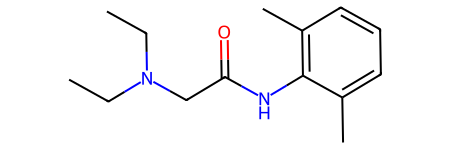

Encoded-Decoded:
CCN(CC)CC(=O)NC1=C(C)C=CC=C1C


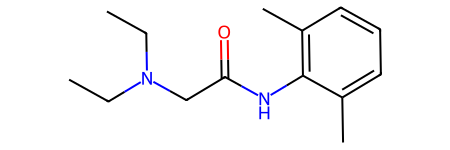



N_x=10, N_y=10, step_size=2



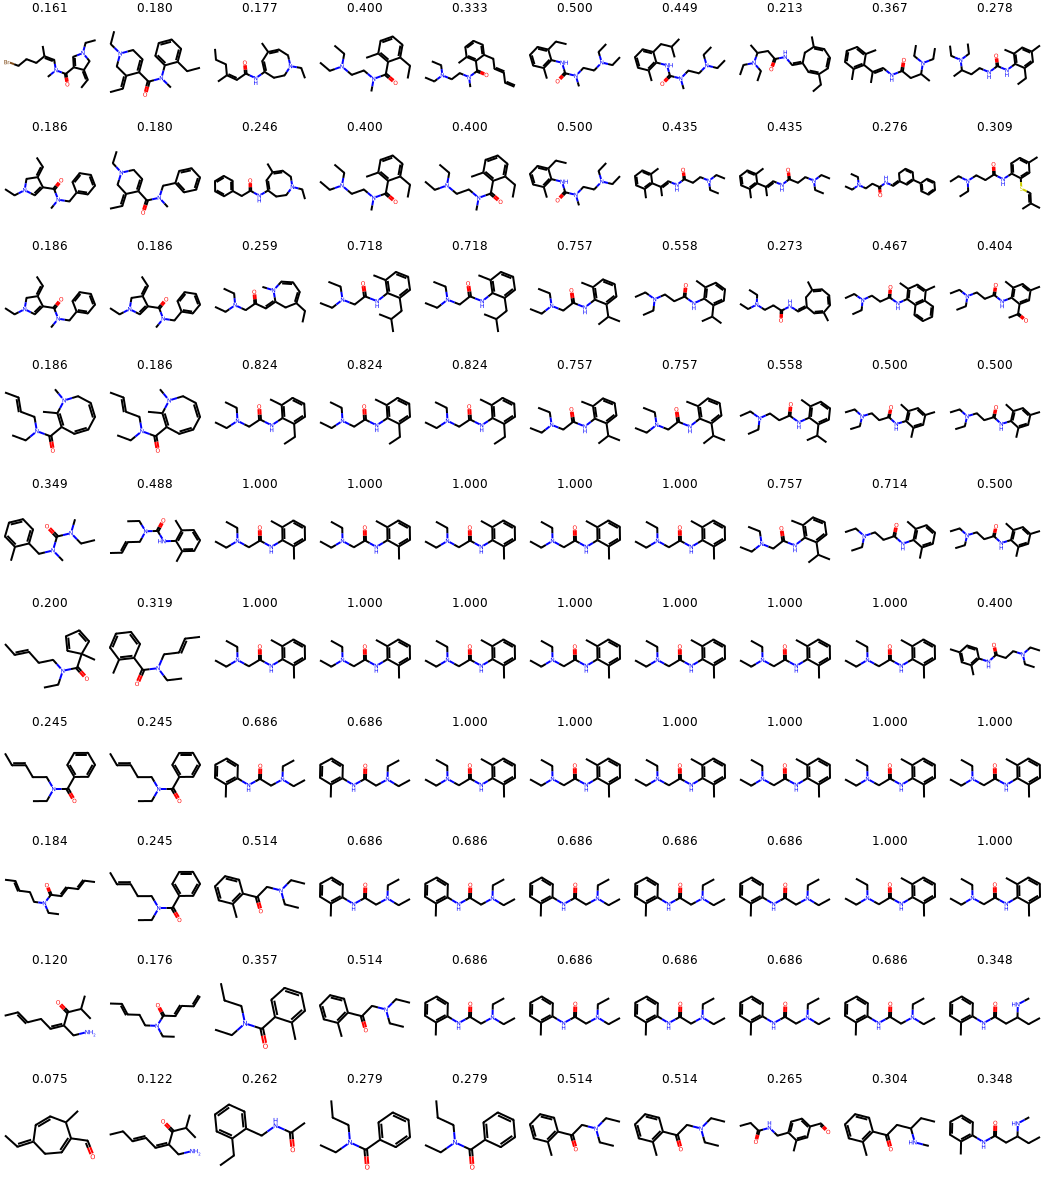

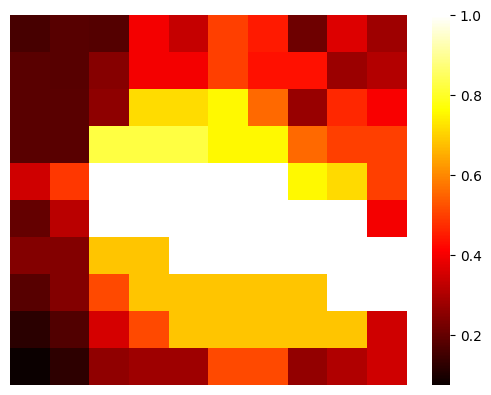

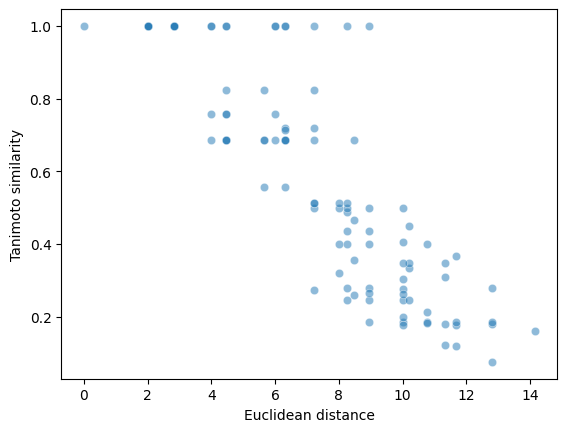

<Figure size 640x480 with 0 Axes>

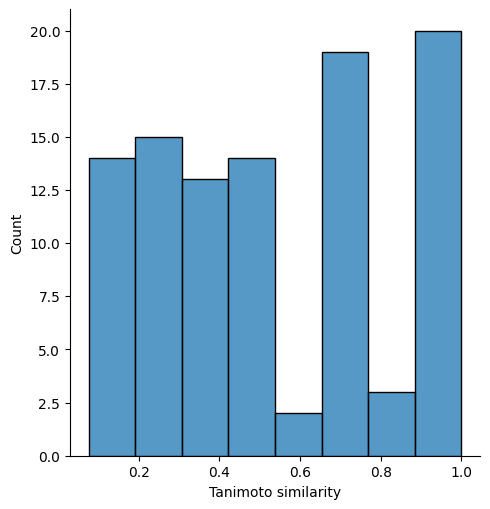

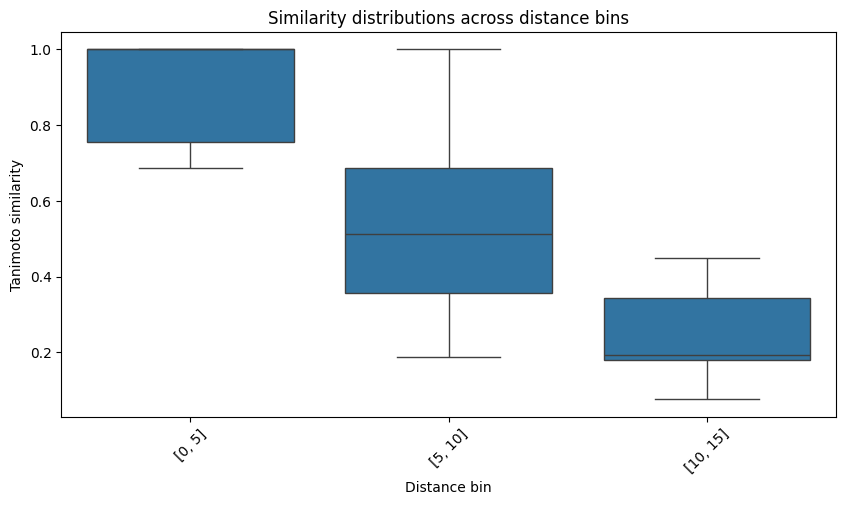

Pearson= -0.8466948377076949
Spearman= -0.8604939130027801


N_x=50, N_y=50, step_size=2



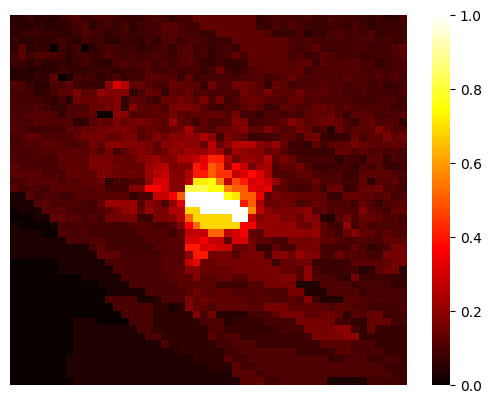

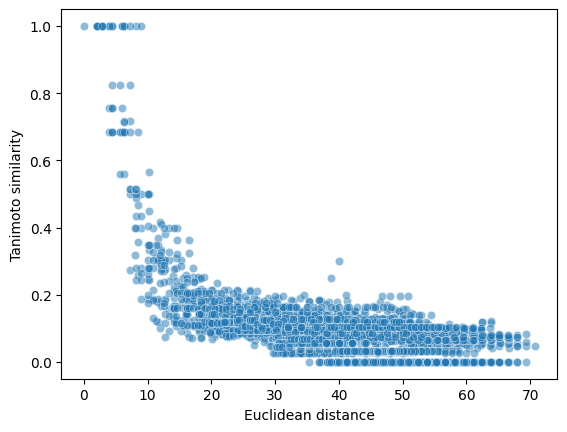

<Figure size 640x480 with 0 Axes>

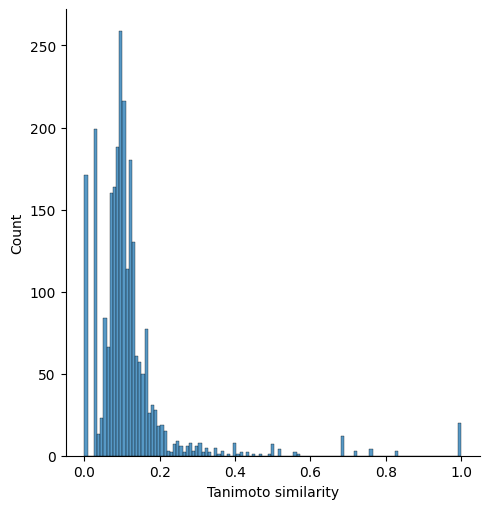

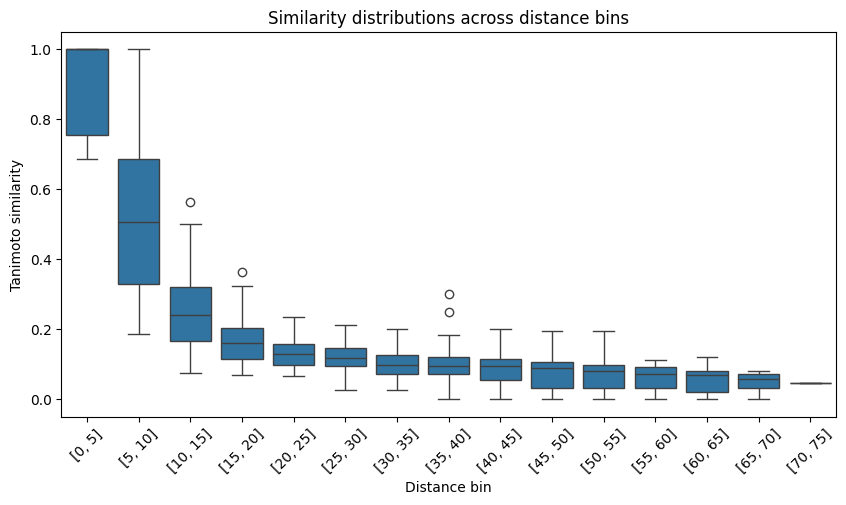

Pearson= -0.5865199639734098
Spearman= -0.5958905359460602


N_x=50, N_y=50, step_size=1



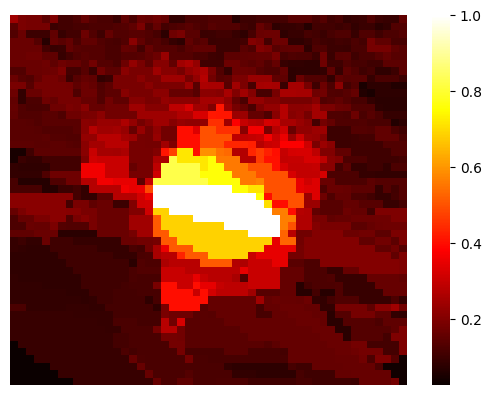

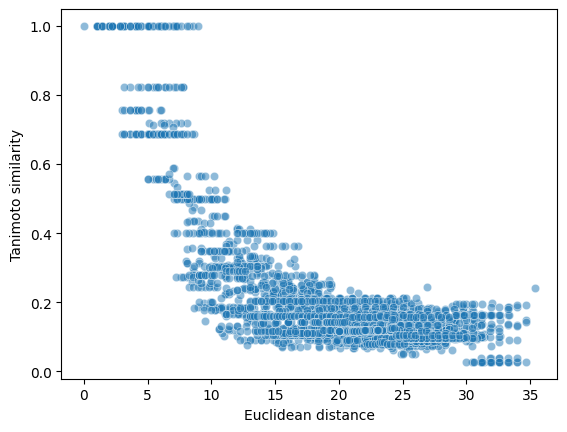

<Figure size 640x480 with 0 Axes>

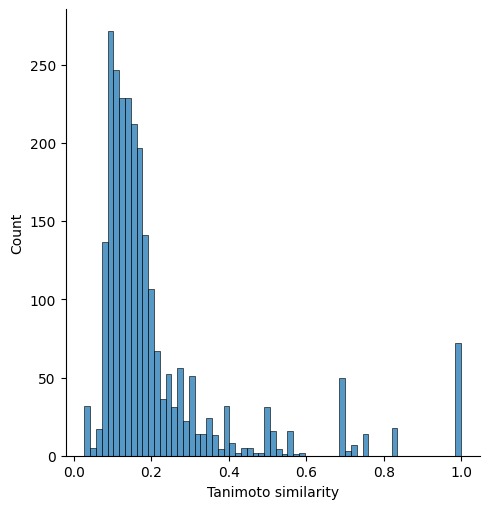

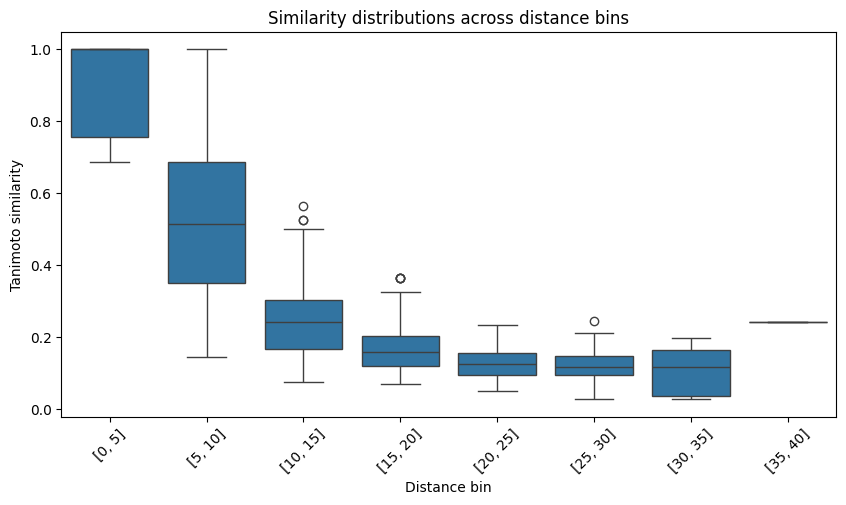

Pearson= -0.7310682851925249
Spearman= -0.6761941401005257


In [3]:
display_everything("CCN(CC)CC(=O)NC1=C(C=CC=C1C)C", vae)